# Hebbian catastrophic forgetting: $architecture

## Simple overview

This notebook trains one **local Hebbian/Oja model** using the repository's
shared data and forgetting functions.

- Architecture: **$architecture**
- Phase 1: digits **0-5**
- Phase 2 sequential: digits **6-9 only**
- Phase 2 interleaved control: the repository's full **0-9** loader
- Full MNIST, batch size **32**, and **20 recorded epochs per phase**
- Learning rate **0.01** for both local hidden and output updates
- Optimizer: **none**; hidden layers never receive backpropagated errors

Run this notebook from top to bottom in a fresh Colab GPU runtime.

## 1. Clone the experiment branch

The notebook does not contain a private copy of the data or class-splitting
code. It clones the branch and imports `src/data.py`, the unchanged
`src/experiments/forgetting.py`, and `src/models/hebbian.py`. A small
Hebbian-specific adapter remains inside this notebook because the shared
forgetting harness currently supports backpropagation only.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/lauraneedham/Catastrophically-Forgotten.git"
BRANCH = "hebbian-learning-v2"
REPO_DIR = Path("/content/Catastrophically-Forgotten")

if REPO_DIR.exists():
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "switch", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", BRANCH], check=True)
else:
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, REPO_URL, str(REPO_DIR)],
        check=True,
    )

os.chdir(REPO_DIR)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

COMMIT_SHA = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True
).strip()
print("Repository:", REPO_DIR)
print("Branch:", BRANCH)
print("Commit:", COMMIT_SHA)

Repository: /content/Catastrophically-Forgotten
Branch: hebbian-learning-v2
Commit: 0b0f223da2a7d51b156de17795a5fc1446320951


## 2. Imports and locked settings

In [2]:
import csv
import inspect
import json
import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data import download_mnist
from src.experiments.forgetting import (
    NEW_CLASSES,
    OLD_CLASSES,
    build_forgetting_loaders,
    plot_forgetting_results,
)
from src.models.base import evaluate_accuracy_stats
from src.models.hebbian import (
    HebbianMultiLayerPerceptron,
    train_hebbian_model,
)

In [3]:
# Team-locked protocol
ARCHITECTURE = "784 -> 100 -> 10"
HIDDEN_SIZES = [100]
BATCH_SIZE = 32
EPOCHS_PHASE1 = 20
EPOCHS_PHASE2 = 20
LEARNING_RATE = 0.01
ACTIVATION = "sigmoid"
BIAS = False
SEED = 0
DATA_SPLIT_SEED = 0
KEEP_PROP = 1.0
TRAIN_PROP = 0.8

# This matches the current shared repository's train_model semantics:
# epoch 1 records an untrained baseline, followed by 19 update epochs.
RECORD_INITIAL_BASELINE = True

# Stops before phase 2 when the model did not learn the old task adequately.
# This is a competence safeguard, not hyperparameter tuning.
MINIMUM_PHASE1_ACCURACY = 80.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Architecture:", ARCHITECTURE)
print("Device:", DEVICE)
print("Old classes:", OLD_CLASSES, "| New classes:", NEW_CLASSES)
print("Learning rate:", LEARNING_RATE, "| Optimizer: none")

Architecture: 784 -> 100 -> 10
Device: cuda
Old classes: [0, 1, 2, 3, 4, 5] | New classes: [6, 7, 8, 9]
Learning rate: 0.01 | Optimizer: none


### Epoch meaning

The current shared repository records epoch 1 as an untrained baseline. With
`20` recorded epochs, each phase therefore contains one baseline record and
nineteen weight-update epochs. This notebook preserves that behavior so it is
comparable with the repository harness.

## 3. Local-learning preflight

In [4]:
print("Imported shared data code from:", inspect.getsourcefile(download_mnist))
print("Imported shared experiment code from:", inspect.getsourcefile(build_forgetting_loaders))
print("Imported Hebbian model code from:", inspect.getsourcefile(HebbianMultiLayerPerceptron))

torch.manual_seed(SEED)
toy_model = HebbianMultiLayerPerceptron(
    num_inputs=12,
    num_hidden=HIDDEN_SIZES,
    num_outputs=10,
    activation_type=ACTIVATION,
    bias=BIAS,
    lr=LEARNING_RATE,
)
toy_X = torch.randn(8, 12)
toy_y = torch.arange(8) % 10
toy_probabilities = toy_model(toy_X)
assert toy_probabilities.shape == (8, 10)
assert torch.allclose(toy_probabilities.sum(1), torch.ones(8), atol=1e-6)
assert all(not parameter.requires_grad for parameter in toy_model.parameters())

updates = toy_model.proposed_updates(toy_X, toy_y)
permuted_updates = toy_model.proposed_updates(toy_X, toy_y.roll(1))
for layer_index in range(len(HIDDEN_SIZES)):
    key = f"hidden_{layer_index}_weight"
    assert torch.equal(updates[key], permuted_updates[key])
assert not torch.equal(updates["output_weight"], permuted_updates["output_weight"])
print("Preflight passed: every hidden update is label-independent; output update is supervised.")

Imported shared data code from: /content/Catastrophically-Forgotten/src/data.py
Imported shared experiment code from: /content/Catastrophically-Forgotten/src/experiments/forgetting.py
Imported Hebbian model code from: /content/Catastrophically-Forgotten/src/models/hebbian.py
Preflight passed: every hidden update is label-independent; output update is supervised.


## 4. Shared MNIST loading and class split

In [5]:
random.seed(DATA_SPLIT_SEED)
np.random.seed(DATA_SPLIT_SEED)
torch.manual_seed(DATA_SPLIT_SEED)
train_set, valid_set, test_set = download_mnist(
    train_prop=TRAIN_PROP,
    keep_prop=KEEP_PROP,
)

preview_loaders = build_forgetting_loaders(
    train_set,
    valid_set,
    batch_size=BATCH_SIZE,
)
sizes = {name: len(loader.dataset) for name, loader in preview_loaders.items()}
sizes["test_set"] = len(test_set)
for name, size in sizes.items():
    print(f"{name:>22}: {size:,}")

# torchvision's fractional random_split may assign the one-image rounding
# remainder to training (48,001/11,999 instead of 48,000/12,000).
assert len(train_set) + len(valid_set) == 60_000
assert abs(len(train_set) - 48_000) <= 1
assert abs(len(valid_set) - 12_000) <= 1
assert len(test_set) == 10_000
assert OLD_CLASSES == [0, 1, 2, 3, 4, 5]
assert NEW_CLASSES == [6, 7, 8, 9]
assert sizes["train_loader_old"] + sizes["train_loader_new"] == len(train_set)
print("Shared full-MNIST and class-split checks passed.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


Number of examples retained:
  48001 (training)
  11999 (validation)
  10000 (test)
      train_loader_old: 28,787
      valid_loader_old: 7,230
      train_loader_new: 19,214
      valid_loader_new: 4,769
     train_loader_full: 48,001
              test_set: 10,000
Shared full-MNIST and class-split checks passed.


## 5. Hebbian adapter and two conditions

Both conditions start from the same seeded model and receive the same phase-1
data order. They differ only in phase 2. If phase-1 validation accuracy is below
the predefined competence gate, execution stops before forgetting is measured.

In [6]:
def run_hebbian_forgetting_experiment(loaders, condition):
    """Hebbian adapter layered on top of the unchanged shared loaders."""
    if condition not in {"sequential", "interleaved"}:
        raise ValueError("condition must be sequential or interleaved")

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = HebbianMultiLayerPerceptron(
        num_inputs=784,
        num_hidden=HIDDEN_SIZES,
        num_outputs=10,
        activation_type=ACTIVATION,
        bias=BIAS,
        lr=LEARNING_RATE,
    ).to(DEVICE)

    # Reset after model initialization so architecture size cannot change the
    # phase-1 shuffle order.
    torch.manual_seed(SEED + 100)
    phase1_results = train_hebbian_model(
        model,
        loaders["train_loader_old"],
        loaders["valid_loader_old"],
        num_epochs=EPOCHS_PHASE1,
        verbose=True,
        record_initial_baseline=RECORD_INITIAL_BASELINE,
    )
    phase1_accuracy = float(phase1_results["avg_valid_accuracies"][-1])
    if phase1_accuracy < MINIMUM_PHASE1_ACCURACY:
        raise RuntimeError(
            f"Phase-1 accuracy {phase1_accuracy:.2f}% did not meet the "
            f"{MINIMUM_PHASE1_ACCURACY:.2f}% competence gate. "
            "Stop before measuring forgetting."
        )

    phase2_loader = (
        loaders["train_loader_new"]
        if condition == "sequential"
        else loaders["train_loader_full"]
    )
    torch.manual_seed(SEED + 200)
    phase2_results = train_hebbian_model(
        model,
        phase2_loader,
        loaders["valid_loader_old"],
        num_epochs=EPOCHS_PHASE2,
        verbose=True,
        record_initial_baseline=RECORD_INITIAL_BASELINE,
    )

    old_trace = (
        phase1_results["avg_valid_accuracies"]
        + phase2_results["avg_valid_accuracies"]
    )
    retained_old = float(phase2_results["avg_valid_accuracies"][-1])
    new_accuracy = float(
        evaluate_accuracy_stats(model, loaders["valid_loader_new"])["accuracy"]
    )
    return {
        "model": model,
        "model_type": "hebbian",
        "condition": condition,
        "architecture": [784, *HIDDEN_SIZES, 10],
        "learning_rates": {
            "hidden_lr": model.hidden_lr,
            "output_lr": model.output_lr,
        },
        "optimizer": "none (direct local Oja and delta updates)",
        "old_class_acc_trace": [float(value) for value in old_trace],
        "phase1_accuracy": phase1_accuracy,
        "retained_old_accuracy": retained_old,
        "forgetting": phase1_accuracy - retained_old,
        "new_class_acc_final": new_accuracy,
        "phase1_epochs": EPOCHS_PHASE1,
        "phase2_epochs": EPOCHS_PHASE2,
        "record_initial_baseline": RECORD_INITIAL_BASELINE,
        "seed": SEED,
        "phase1_results": phase1_results,
        "phase2_results": phase2_results,
    }

In [7]:
results = {}

for condition in ("sequential", "interleaved"):
    # Rebuild the unchanged shared loaders, then reset the data-order seed inside
    # the local adapter. No shared experiment source file is modified.
    loaders = build_forgetting_loaders(
        train_set,
        valid_set,
        batch_size=BATCH_SIZE,
    )
    print(f"\nRunning {condition} condition...")
    results[condition] = run_hebbian_forgetting_experiment(loaders, condition)

assert np.allclose(
    results["sequential"]["phase1_results"]["avg_valid_accuracies"],
    results["interleaved"]["phase1_results"]["avg_valid_accuracies"],
    atol=1e-7,
), "Phase 1 must be identical before the two conditions branch."
print("\nBoth conditions completed and phase-1 traces match.")


Running sequential condition...


  5%|▌         | 1/20 [00:14<04:27, 14.08s/it]

epoch 1 (baseline): train acc = 0.01%, valid acc = 0.01%


 10%|█         | 2/20 [00:23<03:29, 11.63s/it]

epoch 2 (trained): train acc = 80.79%, valid acc = 86.65%


...

 95%|█████████▌| 19/20 [04:49<00:15, 15.78s/it]

epoch 19 (trained): train acc = 79.20%, valid acc = 80.15%


100%|██████████| 20/20 [05:04<00:00, 15.20s/it]

epoch 20 (trained): train acc = 79.83%, valid acc = 78.81%



Both conditions completed and phase-1 traces match.


## 6. Results

In [8]:
summary_rows = []
for condition, result in results.items():
    row = {
        "architecture": ARCHITECTURE,
        "condition": condition,
        "phase1_old_accuracy": result["phase1_accuracy"],
        "retained_old_accuracy": result["retained_old_accuracy"],
        "forgetting": result["forgetting"],
        "new_class_accuracy": result["new_class_acc_final"],
        "learning_rate": LEARNING_RATE,
        "optimizer": result["optimizer"],
        "seed": SEED,
    }
    summary_rows.append(row)

print(
    f"{'condition':<13} {'old before':>11} {'old after':>10} "
    f"{'forgetting':>11} {'new after':>10}"
)
for row in summary_rows:
    print(
        f"{row['condition']:<13} "
        f"{row['phase1_old_accuracy']:>10.2f}% "
        f"{row['retained_old_accuracy']:>9.2f}% "
        f"{row['forgetting']:>10.2f} "
        f"{row['new_class_accuracy']:>9.2f}%"
    )

condition      old before  old after  forgetting  new after
sequential         90.08%      0.00%      90.08     92.54%
interleaved        90.08%     78.81%      11.27     78.21%


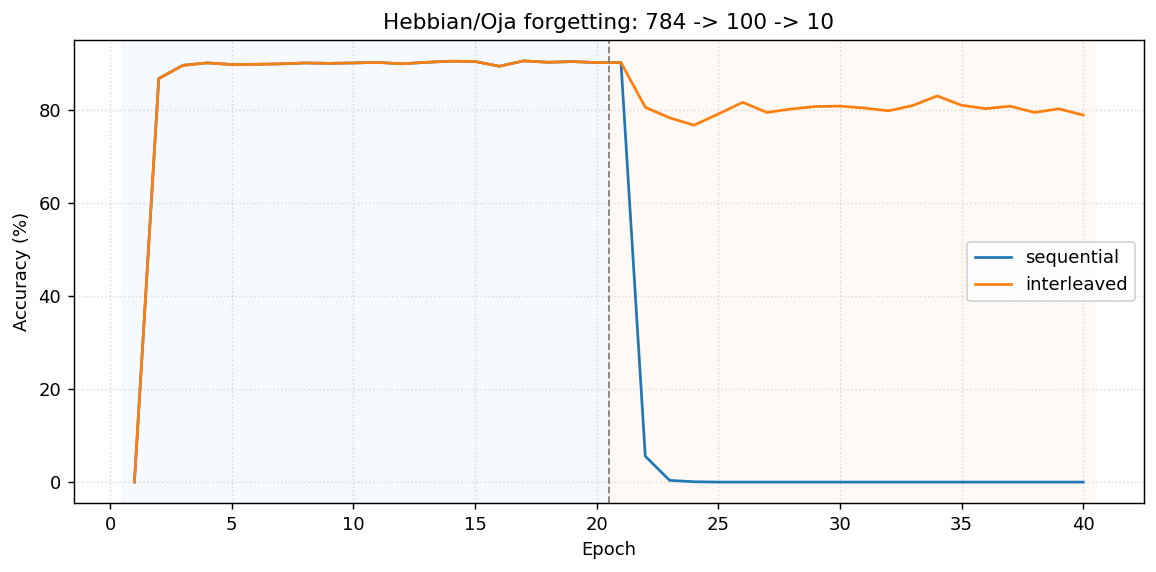

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=130)
plot_forgetting_results(results, ax=ax)
ax.set_title(f"Hebbian/Oja forgetting: {ARCHITECTURE}")
ax.axvspan(0.5, EPOCHS_PHASE1 + 0.5, color="#e6f2ff", alpha=0.35)
ax.axvspan(
    EPOCHS_PHASE1 + 0.5,
    EPOCHS_PHASE1 + EPOCHS_PHASE2 + 0.5,
    color="#fff0e6",
    alpha=0.35,
)
ax.grid(True, linestyle=":", alpha=0.45)
fig.tight_layout()
plt.show()

### Reading the numbers

- **Old before:** performance on digits 0-5 immediately before phase 2.
- **Old after:** retained digits 0-5 performance after phase 2.
- **Forgetting:** old-before minus old-after; larger means worse forgetting.
- **New after:** performance on digits 6-9 after phase 2.

The sequential condition answers the main forgetting question. The interleaved
condition checks whether continued access to old examples prevents the loss.

## 7. Save and download all evidence

In [10]:
OUTPUT_DIR = Path("/content/hebbian_784_100_10_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with (OUTPUT_DIR / "summary.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(summary_rows[0].keys()))
    writer.writeheader()
    writer.writerows(summary_rows)

serializable_results = {}
for condition, result in results.items():
    serializable_results[condition] = {
        key: value
        for key, value in result.items()
        if key not in {"model", "phase1_results", "phase2_results"}
    }
    serializable_results[condition]["phase1_results"] = {
        key: value
        for key, value in result["phase1_results"].items()
        if isinstance(value, list)
    }
    serializable_results[condition]["phase2_results"] = {
        key: value
        for key, value in result["phase2_results"].items()
        if isinstance(value, list)
    }

with (OUTPUT_DIR / "results.json").open("w", encoding="utf-8") as handle:
    json.dump(serializable_results, handle, indent=2)

run_config = {
    "repository": REPO_URL,
    "branch": BRANCH,
    "commit": COMMIT_SHA,
    "architecture": ARCHITECTURE,
    "hidden_sizes": HIDDEN_SIZES,
    "old_classes": OLD_CLASSES,
    "new_classes": NEW_CLASSES,
    "batch_size": BATCH_SIZE,
    "epochs_phase1": EPOCHS_PHASE1,
    "epochs_phase2": EPOCHS_PHASE2,
    "record_initial_baseline": RECORD_INITIAL_BASELINE,
    "learning_rate": LEARNING_RATE,
    "optimizer": "none",
    "activation": ACTIVATION,
    "bias": BIAS,
    "keep_prop": KEEP_PROP,
    "train_prop": TRAIN_PROP,
    "seed": SEED,
    "data_split_seed": DATA_SPLIT_SEED,
    "minimum_phase1_accuracy": MINIMUM_PHASE1_ACCURACY,
    "device": DEVICE,
    "torch_version": torch.__version__,
}
with (OUTPUT_DIR / "run_config.json").open("w", encoding="utf-8") as handle:
    json.dump(run_config, handle, indent=2)

fig.savefig(OUTPUT_DIR / "forgetting_curve.png", bbox_inches="tight")
for condition, result in results.items():
    torch.save(result["model"].state_dict(), OUTPUT_DIR / f"{condition}_model.pt")

archive_path = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
print("Saved result archive:", archive_path)

Saved result archive: /content/hebbian_784_100_10_results.zip


In [11]:
from google.colab import files
files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Hyperparameter policy

This locked run does not search hyperparameters: it uses the team's learning
rate `0.01`. If the phase-1 competence gate fails, any later tuning must use
phase-1 or separate IID validation performance only. Never choose a learning
rate because it produces less forgetting.